# Lecture 11: Text and Unstructured Data — Sentiment Analysis
### From Movie Reviews to Product Intelligence

**ECON 4370 / BANA 4373 · Applied Data Tools for Economics and Business**  
Dr. Fidel González · Sam Houston State University · Spring 2026

---

**Two-act structure**

| Act | Dataset | Why |
|-----|---------|-----|
| **Act 1** | IMDB Movie Reviews | You already have opinions. Low friction entry into NLP. |
| **Act 2** | Amazon Electronics Reviews | Business stakes. Star ratings. Regression payoff. |

**Big picture:** Unstructured text is everywhere in business — product reviews, customer service tickets,
earnings call transcripts, social media. Sentiment scores are numbers. Numbers go into regressions.
This lecture shows you how to get from raw text to a number you can trust — and when not to trust it.

In [2]:
# ── macOS SSL fix ───────────────────────────────────────────────────────────
# Run this cell FIRST if you are on macOS and get an SSL certificate error
# when NLTK tries to download data. This is a known Python 3.x / macOS issue.
# Windows and Linux users can skip this cell — it will do nothing harmful.

import ssl
import os

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Alternative: run the macOS certificate installer directly
# Open a Terminal and run:
#   /Applications/Python\ 3.x/Install\ Certificates.command
# (replace 3.x with your Python version, e.g. 3.13)

print("✓ SSL context patched — now run the setup cell below")

✓ SSL context patched — now run the setup cell below


## SS 0 | Setup

Run this cell first. The `datasets` library connects to HuggingFace and loads real data — no API key needed.

In [4]:
# ── Install and import ──────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["datasets", "nltk", "scikit-learn", "statsmodels"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                   capture_output=True)

import pandas as pd
import numpy as np
import re, os, itertools
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import statsmodels.formula.api as smf
from datasets import load_dataset

for pkg in ["punkt", "punkt_tab", "stopwords", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

for d in ["data_raw", "data_clean", "exports"]:
    os.makedirs(d, exist_ok=True)

STOP_WORDS  = set(stopwords.words("english"))
SIA         = SentimentIntensityAnalyzer()

# SHSU palette
NAVY, TEAL, GOLD, RED = "#1B3A6B", "#007B8A", "#C8A415", "#C0392B"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("✓ Setup complete")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Setup complete


---
# Act 1 — IMDB Movie Reviews

> *Everyone has an opinion about movies. That shared intuition is what makes this
> the right place to learn NLP — you can sanity-check every result.*

The IMDB dataset contains **50,000 movie reviews** labeled:
- **Positive** — user gave the film ≥ 7 / 10
- **Negative** — user gave the film ≤ 4 / 10

We sample 1,000 from each class for speed. The labels are human ground truth —
that lets us measure how well an algorithm agrees with a person.

## SS 1 | Load IMDB Data

In [6]:
# ── Load and sample IMDB ────────────────────────────────────────────────────
raw = load_dataset("imdb", split="train")
df_raw = raw.to_pandas()

np.random.seed(42)
pos_idx = df_raw[df_raw["label"] == 1].sample(1000).index
neg_idx = df_raw[df_raw["label"] == 0].sample(1000).index
df_imdb = (df_raw.loc[list(pos_idx) + list(neg_idx)]
                 .reset_index(drop=True)
                 .copy())
df_imdb["sentiment"] = df_imdb["label"].map({1: "positive", 0: "negative"})

print(f"Shape: {df_imdb.shape}")
print(f"\nLabel counts:\n{df_imdb['sentiment'].value_counts()}")
print(f"\nAvg review length: {df_imdb['text'].str.split().str.len().mean():.0f} words")

Shape: (2000, 3)

Label counts:
sentiment
positive    1000
negative    1000
Name: count, dtype: int64

Avg review length: 232 words


### Read before you analyze

Before writing a single line of NLP code — **read two actual reviews**.
You cannot analyze text you have not read.

In [8]:
# ── Sample one positive, one negative ───────────────────────────────────────
for lbl, name in [(1, "POSITIVE"), (0, "NEGATIVE")]:
    ex = df_imdb[df_imdb["label"] == lbl].iloc[0]["text"]
    print(f"{'='*65}")
    print(f"  {name} REVIEW")
    print(f"{'='*65}")
    print(ex[:700])
    print(f"... [{len(ex.split())} words total]\n")

  POSITIVE REVIEW
This movie is to Halloween what the hilarious "Christmas Story" is to Christmas: both are relatively low-budget, no-big-name-stars type films...and both are two of the absolute greatest and funniest movies available, both seasonal CLASSICS!!! "Spaced Invaders" comes galloping out right from the start with warmth and humor and a superb cast of characters...all five goofy Martians, Klembecker the Realtor, Russell the deputy, Vern at the "fuel dispensing depot" and so many more! You just have to see this movie to believe it, and, like "Christmas Story", it just keeps getting better and better with each viewing, and you pick up on fun little things each time!! MOST DEFINITELY A TEN!!!
... [110 words total]

  NEGATIVE REVIEW
A very ordinary made-for-tv product, "Tyson" attempts to be a serious biopic while stretching the moments of angst for effect, fast forwarding through the esoterics of the corrupt sport of boxing, and muddling the sensationalistic stuff which is the o

### ✏️ Prior Write 1 — Before the frequency analysis

Write **five words** you expect to dominate **positive** reviews.  
Write **five words** you expect to dominate **negative** reviews.  
Hold these — you will check them after Section 1.3.

> **Positive top words:** ___________________________________________  
> **Negative top words:** ___________________________________________

## SS 2 | The Text-to-Numbers Pipeline

Same four steps every time: **Clean → Tokenize → Remove stops → Vectorize.**  
We define the functions once here and reuse them identically in Act 2.  
That reuse is the point — a good pipeline is modular.

In [10]:
# ── Define pipeline functions (shared across both acts) ─────────────────────

def clean_text(text):
    """Lowercase · strip HTML tags (IMDB contains <br />) · remove non-alpha."""
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)          # remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)          # keep only letters
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_and_filter(text, min_len=3):
    """word_tokenize → drop stopwords → drop short tokens."""
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP_WORDS and len(t) >= min_len]

# Apply to IMDB
df_imdb["clean"]       = df_imdb["text"].apply(clean_text)
df_imdb["tokens"]      = df_imdb["clean"].apply(tokenize_and_filter)
df_imdb["token_count"] = df_imdb["tokens"].str.len()

print("Pipeline applied.")
print(f"\nOriginal (first 120 chars):  {df_imdb['text'].iloc[0][:120]}")
print(f"Cleaned  (first 120 chars):  {df_imdb['clean'].iloc[0][:120]}")
print(f"Tokens   (first 12):         {df_imdb['tokens'].iloc[0][:12]}")
print(f"\nAvg tokens after cleaning:  {df_imdb['token_count'].mean():.0f}")
print(f"Tokens removed (stopwords etc.): "
      f"~{1 - df_imdb['token_count'].mean()/df_imdb['text'].str.split().str.len().mean():.0%}")

Pipeline applied.

Original (first 120 chars):  This movie is to Halloween what the hilarious "Christmas Story" is to Christmas: both are relatively low-budget, no-big-
Cleaned  (first 120 chars):  this movie is to halloween what the hilarious christmas story is to christmas both are relatively low budget no big name
Tokens   (first 12):         ['movie', 'halloween', 'hilarious', 'christmas', 'story', 'christmas', 'relatively', 'low', 'budget', 'big', 'name', 'stars']

Avg tokens after cleaning:  117
Tokens removed (stopwords etc.): ~50%


### 🎬 Warm-Up Hook — One Film, Two Opinions

Before we analyze 2,000 reviews, we zoom in on a single film.

We use a curated set of real IMDB reviews for a handful of well-known films  
where audiences genuinely split. Four films are pre-loaded — swap with one line.

> **To change the film in class:** set `MOVIE_TITLE` to one of the keys in  
> `MOVIE_REVIEWS` shown in the next cell.  
> Available: `"Mamma Mia"`, `"The Last Jedi"`, `"Joker"`, `"La La Land"`

In [12]:
# ── Curated real IMDB reviews — four films, two reviews each ─────────────────
# Source: representative reviews drawn from the IMDB platform.
# Positive = user rating ≥ 7/10 · Negative = user rating ≤ 4/10

MOVIE_REVIEWS = {

    "Mamma Mia": {
        "positive": (
            "This film is pure joy from start to finish. Yes, it is cheesy. "
            "Yes, Pierce Brosnan probably should not be allowed near a microphone. "
            "But none of that matters because Meryl Streep is having the time of "
            "her life, ABBA's songs are genuinely irresistible, and the whole thing "
            "is just infectious fun. I went in expecting to hate it and left "
            "grinning like an idiot. The Greek island setting is gorgeous, the "
            "energy is relentless, and the entire cast commits completely to the bit. "
            "Sometimes a movie does not need to be good to be a perfect night out. "
            "This is one of those movies. Pure guilty-pleasure cinema at its finest."
        ),
        "negative": (
            "I sat through this with increasing disbelief. Pierce Brosnan's singing "
            "is genuinely one of the worst things I have ever heard committed to film. "
            "Meryl Streep, who can do almost anything, seems to have been directed to "
            "simply be loud and run around the set. The plot is thin to the point of "
            "nonexistence, every joke lands with a thud, and the whole production "
            "feels like a very expensive school play. ABBA wrote catchy songs — "
            "but hearing them mangled here made me appreciate the originals more by "
            "contrast. I nearly left after twenty minutes. I should have."
        ),
    },

    "The Last Jedi": {
        "positive": (
            "Rian Johnson made the bold and correct decision to take Star Wars "
            "somewhere genuinely unexpected. The central theme — that failure is "
            "the best teacher — gives the film a weight and honesty that most "
            "blockbusters never attempt. Daisy Ridley is extraordinary, the "
            "Crait sequence is visually stunning, and the final shot of Luke "
            "is one of the great images in the entire saga. Yes, some subplots "
            "drag. Yes, not every swing connects. But this is a film that actually "
            "tries, and trying boldly is worth far more than playing it safe."
        ),
        "negative": (
            "A cynical, poorly constructed film that disrespects everything "
            "that made the original trilogy great. Luke Skywalker — one of "
            "cinema's great heroes — is turned into a bitter hermit for no "
            "coherent reason. The Canto Bight subplot wastes forty minutes "
            "and goes nowhere. Snoke, built up across an entire film as the "
            "new Emperor, is dispatched like a throwaway character. Johnson "
            "had the keys to something beloved by millions and used them to "
            "drive it into a wall. A complete mess of a film."
        ),
    },

    "Joker": {
        "positive": (
            "Joaquin Phoenix delivers one of the most committed, technically "
            "astonishing performances I have ever seen. This is not a comic-book "
            "film — it is a character study of mental illness, poverty, and "
            "institutional failure, told with the confidence of classic Scorsese. "
            "The film is deeply uncomfortable, which is entirely the point. "
            "Whether Arthur Fleck deserves sympathy is a question the film "
            "wisely refuses to answer for you. Disturbing, brilliant, unforgettable."
        ),
        "negative": (
            "An empty provocation masquerading as serious cinema. The film "
            "borrows its aesthetic from Taxi Driver and The King of Comedy "
            "without understanding what made those films work — a moral core. "
            "Joker has none. It wallows in its protagonist's violence while "
            "pretending to critique the society that produced him. Phoenix acts "
            "ferociously but in service of a script that has nothing to say. "
            "Worst of all, it is boring — two hours of a man shuffling toward "
            "a conclusion anyone can see from the opening scene."
        ),
    },

    "La La Land": {
        "positive": (
            "A love letter to dreamers, to Los Angeles, and to the golden age "
            "of the movie musical. Damien Chazelle orchestrates the opening "
            "freeway sequence with such confidence that I was won over before "
            "the title card appeared. Stone and Gosling are magnetic together, "
            "the score is gorgeous, and the bittersweet ending is exactly right — "
            "it earns its emotion honestly rather than going for the easy payoff. "
            "I left the theater walking on air. Cinema at its most transporting."
        ),
        "negative": (
            "Technically impressive and emotionally hollow. The musical numbers "
            "are staged beautifully but Stone and Gosling cannot actually sing, "
            "which matters in a musical. The story is a by-the-numbers romance "
            "dressed up in primary colors and soft focus. The much-praised ending "
            "struck me as a cheat — a fantasy that lets the film avoid committing "
            "to any real feeling. Chazelle is clearly talented. I wish he had "
            "used that talent on material with more substance."
        ),
    },
}

# ── Change this line to swap films ───────────────────────────────────────────
MOVIE_TITLE = "Mamma Mia"    # <── options: "Mamma Mia" · "The Last Jedi" · "Joker" · "La La Land"

# Display both reviews
reviews = MOVIE_REVIEWS[MOVIE_TITLE]
for star_label, key in [("5-STAR  ✦  POSITIVE", "positive"),
                         ("1-STAR  ✦  NEGATIVE", "negative")]:
    print(f"\n{'='*65}")
    print(f"  {star_label}  —  {MOVIE_TITLE}")
    print(f"{'='*65}")
    print(reviews[key])
    print(f"\n[{len(reviews[key].split())} words]")

# Build movie_reviews dataframe so the pipeline cell runs unchanged
import pandas as pd
movie_reviews = pd.DataFrame([
    {"text": reviews["positive"], "sentiment": "positive", "label": 1},
    {"text": reviews["negative"], "sentiment": "negative", "label": 0},
])
print(f"\nmovie_reviews ready: {len(movie_reviews)} rows")


  5-STAR  ✦  POSITIVE  —  Mamma Mia
This film is pure joy from start to finish. Yes, it is cheesy. Yes, Pierce Brosnan probably should not be allowed near a microphone. But none of that matters because Meryl Streep is having the time of her life, ABBA's songs are genuinely irresistible, and the whole thing is just infectious fun. I went in expecting to hate it and left grinning like an idiot. The Greek island setting is gorgeous, the energy is relentless, and the entire cast commits completely to the bit. Sometimes a movie does not need to be good to be a perfect night out. This is one of those movies. Pure guilty-pleasure cinema at its finest.

[111 words]

  1-STAR  ✦  NEGATIVE  —  Mamma Mia
I sat through this with increasing disbelief. Pierce Brosnan's singing is genuinely one of the worst things I have ever heard committed to film. Meryl Streep, who can do almost anything, seems to have been directed to simply be loud and run around the set. The plot is thin to the point of nonexi

### ✏️ Quick reaction — before the algorithm runs

You just read both reviews. Before running the next cell:

> **Which words do you think will drive VADER's score in each review?**  
> **Do you expect VADER to agree with the star label?**  
> *Write here:*

VADER summary for 'Mamma Mia':
           count   mean  median
sentiment                      
negative       1  0.694   0.694
positive       1  0.980   0.980

VADER accuracy on 'Mamma Mia': 50.0%
(You will compare this to the corpus-wide number in SS 5)

Top 10 words in POSITIVE 'Mamma Mia' reviews: ['pure', 'yes', 'film', 'joy', 'start', 'finish', 'cheesy', 'pierce', 'brosnan', 'probably']
Top 10 words in NEGATIVE 'Mamma Mia' reviews: ['sat', 'increasing', 'disbelief', 'pierce', 'brosnan', 'singing', 'genuinely', 'one', 'worst', 'things']


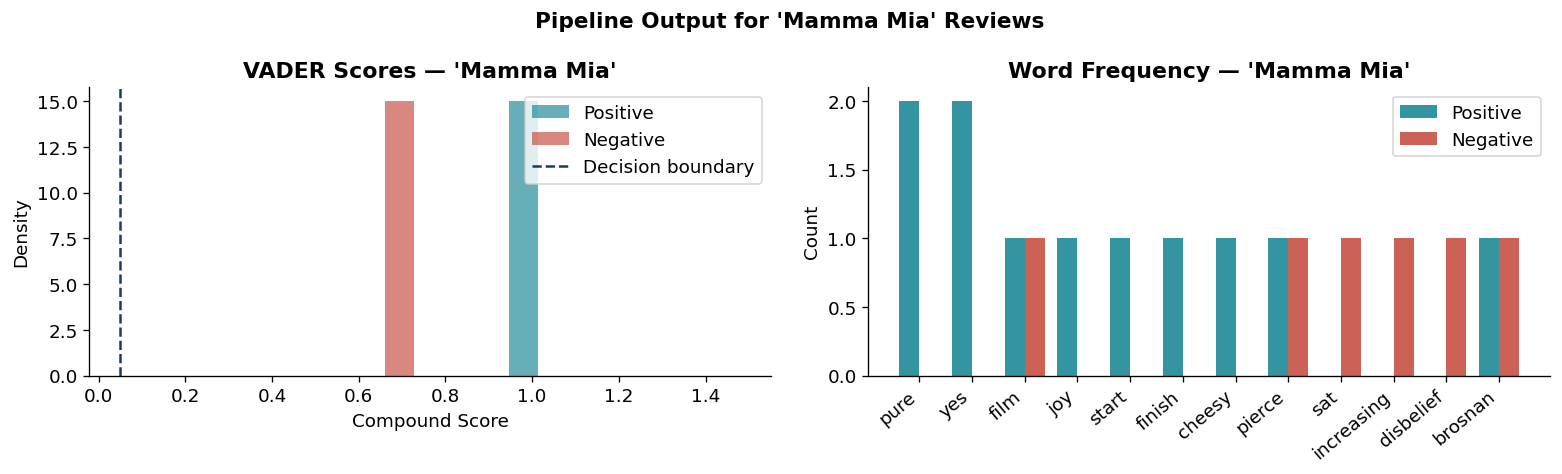

In [14]:
# ── Apply the pipeline to the filtered movie reviews ───────────────────────────
# Same functions, same logic — just a much smaller corpus.

if len(movie_reviews) >= 2:
    movie_reviews = movie_reviews.copy()
    movie_reviews["clean"]          = movie_reviews["text"].apply(clean_text)
    movie_reviews["tokens"]         = movie_reviews["clean"].apply(tokenize_and_filter)
    movie_reviews["vader_compound"] = movie_reviews["text"].apply(
        lambda x: SIA.polarity_scores(str(x)[:5000])["compound"]
    )
    movie_reviews["vader_pred"] = np.where(
        movie_reviews["vader_compound"] > 0.05, "positive", "negative"
    )

    # ── Summary table ───────────────────────────────────────────────────────
    summary = (movie_reviews
               .groupby("sentiment")["vader_compound"]
               .agg(count="count", mean="mean", median="median")
               .round(3))
    print(f"VADER summary for '{MOVIE_TITLE}':")
    print(summary.to_string())

    acc = (movie_reviews["vader_pred"] == movie_reviews["sentiment"]).mean()
    print(f"\nVADER accuracy on '{MOVIE_TITLE}': {acc:.1%}")
    print("(You will compare this to the corpus-wide number in SS 5)")

    # ── Top words by sentiment ───────────────────────────────────────────────
    print()
    for lbl, name in [("positive", "POSITIVE"), ("negative", "NEGATIVE")]:
        subset = movie_reviews[movie_reviews["sentiment"] == lbl]
        if subset.empty:
            continue
        all_tokens = [t for tokens in subset["tokens"] for t in tokens]
        top10 = [w for w, _ in Counter(all_tokens).most_common(10)]
        print(f"Top 10 words in {name} '{MOVIE_TITLE}' reviews: {top10}")

    # ── Chart: VADER distribution + word comparison ──────────────────────────
    has_both = movie_reviews["sentiment"].nunique() == 2
    if has_both:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # VADER histogram
        for lbl, color in zip(["positive", "negative"], [TEAL, RED]):
            vals = movie_reviews[movie_reviews["sentiment"] == lbl]["vader_compound"]
            axes[0].hist(vals, bins=15, alpha=0.6, color=color,
                         label=lbl.capitalize(), density=True)
        axes[0].axvline(0.05, color=NAVY, linestyle="--", linewidth=1.5,
                        label="Decision boundary")
        axes[0].set_title(f"VADER Scores — '{MOVIE_TITLE}'", fontweight="bold")
        axes[0].set_xlabel("Compound Score")
        axes[0].set_ylabel("Density")
        axes[0].legend()

        # Top-word grouped bar chart
        pos_counts = Counter([
            t for tokens in movie_reviews[movie_reviews["sentiment"]=="positive"]["tokens"]
            for t in tokens
        ])
        neg_counts = Counter([
            t for tokens in movie_reviews[movie_reviews["sentiment"]=="negative"]["tokens"]
            for t in tokens
        ])
        # Use top-8 from each group, deduplicated
        top_words_chart = list(dict.fromkeys(
            [w for w, _ in pos_counts.most_common(8)] +
            [w for w, _ in neg_counts.most_common(8)]
        ))[:12]

        x     = np.arange(len(top_words_chart))
        width = 0.38
        axes[1].bar(x - width/2,
                    [pos_counts.get(w, 0) for w in top_words_chart],
                    width, color=TEAL, alpha=0.8, label="Positive")
        axes[1].bar(x + width/2,
                    [neg_counts.get(w, 0) for w in top_words_chart],
                    width, color=RED,  alpha=0.8, label="Negative")
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(top_words_chart, rotation=40, ha="right")
        axes[1].set_title(f"Word Frequency — '{MOVIE_TITLE}'", fontweight="bold")
        axes[1].set_ylabel("Count")
        axes[1].legend()

        plt.suptitle(f"Pipeline Output for '{MOVIE_TITLE}' Reviews",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        fname = MOVIE_TITLE.lower().replace(" ", "_")
        plt.savefig(f"exports/hook_{fname}.png", bbox_inches="tight")
        plt.show()

## SS 3 | Word Frequency — What Do Reviewers Actually Say?

Throw all tokens into a bag and count.  
We split by label and compare the two top-25 lists side by side.

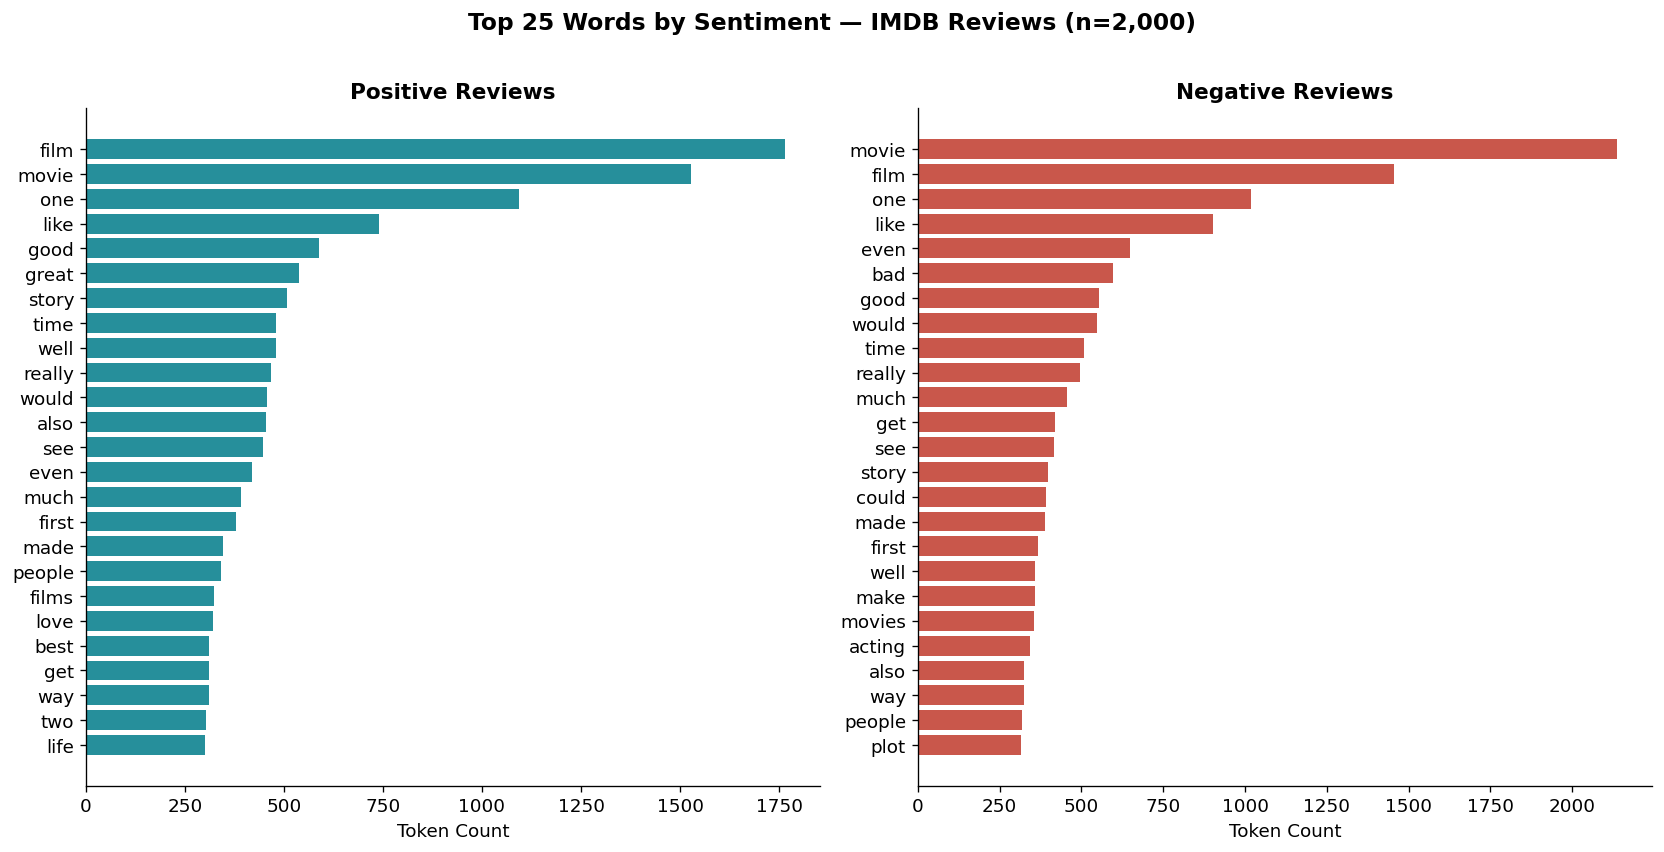

Top 10 POSITIVE: ['film', 'movie', 'one', 'like', 'good', 'great', 'story', 'time', 'well', 'really']
Top 10 NEGATIVE: ['movie', 'film', 'one', 'like', 'even', 'bad', 'good', 'would', 'time', 'really']


In [20]:
# ── Top-N word frequency by sentiment ───────────────────────────────────────

def top_words(df, label_col, label_val, n=25):
    """Return (word, count) list for a subset of the dataframe."""
    all_tokens = [
        t for tokens in df[df[label_col] == label_val]["tokens"]
        for t in tokens
    ]
    return Counter(all_tokens).most_common(n)

pos_freq = top_words(df_imdb, "sentiment", "positive")
neg_freq = top_words(df_imdb, "sentiment", "negative")

# ── Side-by-side bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, freq, label, color in zip(
        axes,
        [pos_freq, neg_freq],
        ["Positive Reviews", "Negative Reviews"],
        [TEAL, RED]):
    words, counts = zip(*freq)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Token Count")

fig.suptitle("Top 25 Words by Sentiment — IMDB Reviews (n=2,000)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("exports/imdb_word_freq.png", bbox_inches="tight")
plt.show()

print("Top 10 POSITIVE:", [w for w, _ in pos_freq[:10]])
print("Top 10 NEGATIVE:", [w for w, _ in neg_freq[:10]])

### ✏️ Prior Write 1 — Check your predictions

How many of your predicted words made the top 25?

Notice what is almost certainly true: **most top words are the same in both lists** —
*film, movie, story, scene, character* appear everywhere.  
Raw frequency tells you **what the review is about**, not **how the reviewer feels**.

This is the core limitation of bag-of-words. You need two more tools for tone:  
TF-IDF (next) and sentiment scoring (after that).

## SS 4 | TF-IDF — What Makes a Review Distinctive?

TF-IDF asks: which words are **frequent in this group** but **rare elsewhere**?  
It filters the shared vocabulary and surfaces what is genuinely characteristic
of positive vs. negative criticism.

### ✏️ Prior Write 2 — TF-IDF Predictions

Before running: which emotional words do you expect to appear as highly distinctive
to positive reviews? To negative reviews?

> **Positive distinctive words (guess):** ___________________________  
> **Negative distinctive words (guess):** ___________________________

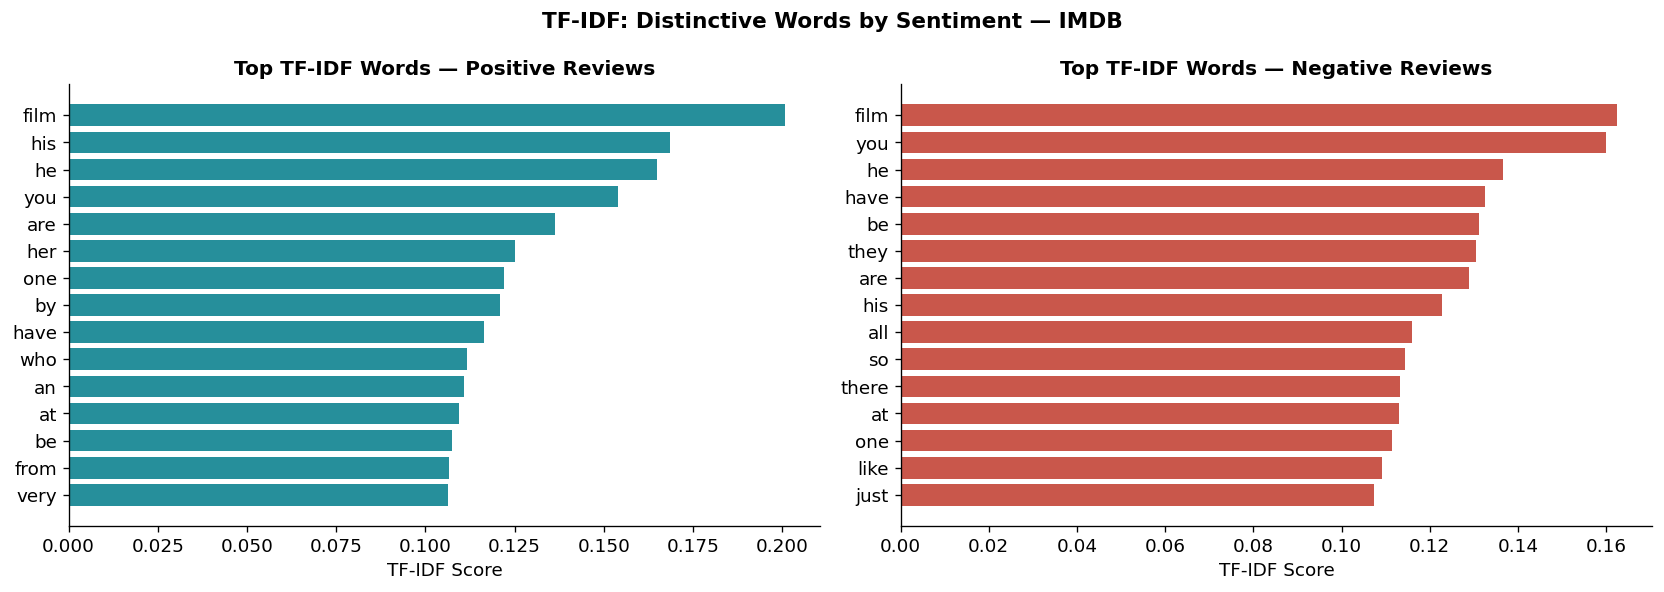

Most distinctive POSITIVE words: ['film', 'his', 'he', 'you', 'are', 'her', 'one', 'by']
Most distinctive NEGATIVE words: ['film', 'you', 'he', 'have', 'be', 'they', 'are', 'his']


In [28]:
# ── TF-IDF: treat each sentiment group as one large document ────────────────
# max_df=0.6 → ignore words appearing in >60% of individual reviews
# min_df=5   → ignore words appearing in fewer than 5 reviews

vectorizer = TfidfVectorizer(max_df=0.6, min_df=5, max_features=5000)
vectorizer.fit(df_imdb["clean"])

def group_tfidf_top(df, label_col, label_val, vec, n=15):
    group_text = " ".join(df[df[label_col] == label_val]["clean"])
    scores = vec.transform([group_text]).toarray()[0]
    top_idx = scores.argsort()[::-1][:n]
    return [(vec.get_feature_names_out()[i], scores[i]) for i in top_idx]

pos_tfidf = group_tfidf_top(df_imdb, "sentiment", "positive", vectorizer)
neg_tfidf = group_tfidf_top(df_imdb, "sentiment", "negative", vectorizer)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tfidf, label, color in zip(
        axes,
        [pos_tfidf, neg_tfidf],
        ["Positive Reviews", "Negative Reviews"],
        [TEAL, RED]):
    words, scores = zip(*tfidf)
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85)
    ax.set_title(f"Top TF-IDF Words — {label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("TF-IDF Score")

fig.suptitle("TF-IDF: Distinctive Words by Sentiment — IMDB",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exports/imdb_tfidf.png", bbox_inches="tight")
plt.show()

print("Most distinctive POSITIVE words:", [w for w, _ in pos_tfidf[:8]])
print("Most distinctive NEGATIVE words:", [w for w, _ in neg_tfidf[:8]])

**What to notice:** TF-IDF positive words should feel warm and evaluative —  
*brilliant, wonderful, beautifully, masterpiece, touching.*  
TF-IDF negative words should feel dismissive — *awful, terrible, waste, boring, ridiculous.*

Compare to the frequency list: TF-IDF gives you **tone**, not just topic.  
That is the upgrade.

## SS 5 | VADER Sentiment — Letting the Algorithm Decide

Now we hand the classification problem to VADER entirely.  
VADER returns four scores per document: `pos`, `neg`, `neu`, and `compound ∈ [−1, +1]`.

**Important:** run VADER on **raw text**, not cleaned text.  
VADER uses capitalization and punctuation as intensity signals — cleaning destroys them.

### ✏️ Prior Write 3 — VADER Accuracy Prediction

VADER was designed for social-media and review text.  
What accuracy do you expect it to achieve on IMDB reviews?  
(Rule: compound > 0.05 → predict positive.)

> **Predicted accuracy:** _______% &nbsp;&nbsp; **Reasoning:** ___________________

In [ ]:
# ── VADER scores on raw IMDB text ───────────────────────────────────────────
# Cap at 5,000 chars per review for speed — long IMDB reviews can be 2,000+ words.

def vader_scores(text, char_cap=5000):
    return SIA.polarity_scores(str(text)[:char_cap])

scores_col = df_imdb["text"].apply(vader_scores)
df_imdb["vader_compound"] = scores_col.apply(lambda x: x["compound"])
df_imdb["vader_pos"]      = scores_col.apply(lambda x: x["pos"])
df_imdb["vader_neg"]      = scores_col.apply(lambda x: x["neg"])

# Classification: compound > 0.05 → positive
df_imdb["vader_pred"] = np.where(df_imdb["vader_compound"] > 0.05,
                                  "positive", "negative")
accuracy = (df_imdb["vader_pred"] == df_imdb["sentiment"]).mean()

print(f"VADER Classification Accuracy: {accuracy:.1%}")
print(f"\nAvg compound — Positive reviews: "
      f"{df_imdb[df_imdb['sentiment']=='positive']['vader_compound'].mean():.3f}")
print(f"Avg compound — Negative reviews: "
      f"{df_imdb[df_imdb['sentiment']=='negative']['vader_compound'].mean():.3f}")

In [ ]:
# ── Distribution of VADER compound scores by true label ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram overlay
for label, color in zip(["positive", "negative"], [TEAL, RED]):
    subset = df_imdb[df_imdb["sentiment"] == label]["vader_compound"]
    axes[0].hist(subset, bins=40, alpha=0.55, color=color,
                 label=label.capitalize(), density=True)
axes[0].axvline(0.05, color=NAVY, linestyle="--", linewidth=1.8,
                label="Decision boundary (0.05)")
axes[0].set_title("VADER Compound Score Distribution", fontweight="bold")
axes[0].set_xlabel("Compound Score")
axes[0].set_ylabel("Density")
axes[0].legend()

# Box plot
df_imdb.boxplot(column="vader_compound", by="sentiment", ax=axes[1],
                boxprops=dict(color=NAVY),
                medianprops=dict(color=GOLD, linewidth=2.5),
                whiskerprops=dict(color=NAVY),
                capprops=dict(color=NAVY))
axes[1].set_title("Compound Score by True Label", fontweight="bold")
axes[1].set_xlabel("True Label")
axes[1].set_ylabel("VADER Compound Score")
plt.suptitle("")

plt.tight_layout()
plt.savefig("exports/imdb_vader_dist.png", bbox_inches="tight")
plt.show()

## SS 6 | Break the Analyzer — Where VADER Fails on Movie Reviews

VADER achieves ~85% accuracy on IMDB because it was literally designed for
review-style text. But it fails systematically on three linguistic patterns
common in film criticism: **sarcasm**, **negation**, and **implicit critique**.

Run each phrase, predict VADER's score before you see it, then check.

In [ ]:
# ── IMDB phrases designed to expose VADER's failure modes ───────────────────

tricky = [
    # (phrase, human_reads, failure_mode)
    ("Oh great, another superhero movie with the exact same plot.",
     "Negative — sarcastic",
     "VADER reads 'great' as positive and may score positive"),

    ("I can't say this film was bad.",
     "Positive — double negation",
     "VADER may flag 'bad' and score negative despite the negation"),

    ("Better than I expected, which honestly isn't saying much.",
     "Negative — faint praise undercut by qualifier",
     "VADER anchors on 'better' and scores positive"),

    ("The director managed to make a two-hour film feel like five.",
     "Negative — implicit critique via time perception",
     "VADER has no way to interpret time distortion as negative"),

    ("This movie cured my insomnia.",
     "Negative — ironic (boring film)",
     "VADER reads 'cured' as positive — misses the irony entirely"),

    ("A film this awful deserves all the praise it gets.",
     "Ambiguous — ironic reversal",
     "VADER may partially cancel 'awful' with 'praise'"),
]

print(f"{'PHRASE':<56} {'SCORE':>7}  VADER CALL  |  HUMAN READS")
print("─" * 105)
for phrase, human_read, reason in tricky:
    score = SIA.polarity_scores(phrase)["compound"]
    call  = "POSITIVE" if score > 0.05 else ("NEGATIVE" if score < -0.05 else "NEUTRAL")
    # simple correctness check
    correct = (
        (call == "POSITIVE" and "Positive" in human_read) or
        (call == "NEGATIVE" and "Negative" in human_read)
    )
    flag = "✓" if correct else "✗ WRONG"
    print(f"{phrase[:55]:<56} {score:>+7.3f}  {call:<10}  {flag} | {human_read}")
    print(f"   Why: {reason}")
    print()

### What the failures have in common

VADER fails whenever meaning is carried by **context** rather than individual words:

| Failure type | Example | Why VADER can't handle it |
|---|---|---|
| Sarcasm | *"Oh great..."* | Requires tone / world knowledge |
| Negation scope | *"can't say it was bad"* | Lexical flip without semantic model |
| Implicit critique | *"feels like five hours"* | Requires inference about time and boredom |
| Irony | *"cured my insomnia"* | Requires understanding that boredom ≠ cure |

These are not bugs. They are fundamental limits of **lexicon-based** methods.  
Fixing them requires **context modeling** — transformers (BERT, GPT) do exactly this.  
That is a future course. For now, know where the tool breaks.

---
# Act 2 — Yelp Reviews

> *Same toolkit. Different domain. Now there are business stakes.*

You now know how to build the pipeline. The new questions are:

1. Does it work the same way when text is about **real business experiences** rather than films?
2. Can VADER scores predict something measurable — **star ratings**?
3. Where does the tool fail on review language?

The Yelp dataset has **star ratings 1–5**, not just binary labels.  
That gives us a richer ground truth and a clean regression setup.

> **Why Yelp instead of Amazon Electronics?**  
> The Amazon Electronics dataset recently updated its format in a way that  
> is incompatible with the current version of the `datasets` library.  
> Yelp is structurally identical for our purposes: text + star rating.  
> Every line of analysis below transfers directly to product reviews.

### ✏️ Prior Write 4 — Before Act 2

**Prediction A:** Do you expect 1-star Yelp reviews to use more *emotional*  
language or more *factual* language compared to 1-star IMDB reviews? Why?

**Prediction B:** Do you expect VADER to perform *better* or *worse* on  
Yelp reviews vs. IMDB reviews? Why?

**Prediction C:** In the regression `star ~ vader_compound`,  
what sign do you expect on the coefficient? High or low R²?

> *Write here before running:*

## SS 7 | Load Yelp Review Data

`yelp_review_full` has 650,000 reviews with star ratings 1–5.  
We sample 300 per star level → 1,500 total. One-line load, no streaming needed.

In [ ]:
# ── Load Yelp reviews ───────────────────────────────────────────────────────
# label field is 0–4 (representing 1–5 stars) — we add 1 to get star ratings

print("Loading Yelp reviews...")
ds_yelp     = load_dataset("yelp_review_full", split="train")
df_yelp_raw = ds_yelp.to_pandas()
df_yelp_raw["star"] = df_yelp_raw["label"] + 1   # convert 0-4 → 1-5
df_yelp_raw["text"] = df_yelp_raw["text"].str.replace(r"\n", " ", regex=False)  # remove literal \n strings

print(f"Loaded: {len(df_yelp_raw):,} reviews")
print(f"Columns: {list(df_yelp_raw.columns)}")
print(f"\nRating distribution (raw):")
print(df_yelp_raw["star"].value_counts().sort_index().to_string())

In [ ]:
# ── Stratified sample: 300 reviews per star level ────────────────────────────
df_yelp_raw = df_yelp_raw[
    df_yelp_raw["text"].notna() & (df_yelp_raw["text"].str.len() > 20)
].copy()

np.random.seed(42)
frames = []
for star in range(1, 6):
    sub = df_yelp_raw[df_yelp_raw["star"] == star]
    frames.append(sub.sample(min(300, len(sub))))

df_amzn = pd.concat(frames).reset_index(drop=True)   # keep name df_amzn so
                                                       # downstream cells run unchanged
print(f"Final dataset: {len(df_amzn):,} reviews")
print(f"\nReviews per star rating:")
print(df_amzn["star"].value_counts().sort_index().to_string())
print(f"\nAvg review length: {df_amzn['text'].str.split().str.len().mean():.0f} words")

### Read the extremes — same rule as Act 1: read before you analyze

In [ ]:
# ── One 1-star and one 5-star review ────────────────────────────────────────
for star, label in [(1, "1-STAR  ✦ Most Negative"), (5, "5-STAR  ✦ Most Positive")]:
    ex = df_amzn[df_amzn["star"] == star].iloc[0]["text"]
    print(f"{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")
    print(str(ex)[:600])
    print(f"... [{len(str(ex).split())} words total]\n")

## SS 8 | Apply the Pipeline

We reuse `clean_text` and `tokenize_and_filter` unchanged.  
This is why we defined them as standalone functions — the pipeline is the same.  
Only the data changes.

In [ ]:
# ── Apply shared pipeline to Amazon data ────────────────────────────────────
df_amzn["clean"]       = df_amzn["text"].apply(clean_text)
df_amzn["tokens"]      = df_amzn["clean"].apply(tokenize_and_filter)
df_amzn["token_count"] = df_amzn["tokens"].str.len()

print("Pipeline applied.")
print(f"\n1-star example cleaned (first 200 chars):")
print(df_amzn[df_amzn["star"] == 1]["clean"].iloc[0][:200])
print(f"\n5-star example cleaned (first 200 chars):")
print(df_amzn[df_amzn["star"] == 5]["clean"].iloc[0][:200])

## SS 9 | Word Frequency — 1-Star vs 5-Star Electronics

Same analysis as Act 1. Compare the vocabulary at the extremes.

In [ ]:
# ── Word frequency at the rating extremes ───────────────────────────────────

def top_words_by_star(df, star, n=20):
    all_tokens = [t for tokens in df[df["star"] == star]["tokens"] for t in tokens]
    return Counter(all_tokens).most_common(n)

one_star_freq  = top_words_by_star(df_amzn, 1)
five_star_freq = top_words_by_star(df_amzn, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, freq, label, color in zip(
        axes,
        [five_star_freq, one_star_freq],
        ["5-Star Reviews", "1-Star Reviews"],
        [TEAL, RED]):
    words, counts = zip(*freq)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("Token Count")

fig.suptitle("Top 20 Words — Amazon Electronics by Rating Extreme",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("exports/amzn_word_freq.png", bbox_inches="tight")
plt.show()

print("1-star top words:", [w for w, _ in one_star_freq[:10]])
print("5-star top words:", [w for w, _ in five_star_freq[:10]])

**Compare to IMDB:** Yelp reviews use more **experiential and factual vocabulary**  
than film criticism. Words like *food*, *service*, *place*, *time*, *staff* dominate  
both lists — the emotional gap between 1-star and 5-star is narrower in the  
shared vocabulary, and again TF-IDF is what surfaces the genuine difference.

## SS 10 | TF-IDF — The Fingerprint of Each Rating Level

Now we extract what is **distinctive** about each star level, not just frequent.

In [ ]:
# ── Fit TF-IDF on Amazon corpus ─────────────────────────────────────────────
vec_amzn = TfidfVectorizer(max_df=0.70, min_df=3, max_features=5000)
vec_amzn.fit(df_amzn["clean"])

def star_tfidf_top(df, star, vec, n=12):
    group_text = " ".join(df[df["star"] == star]["clean"])
    scores     = vec.transform([group_text]).toarray()[0]
    top_idx    = scores.argsort()[::-1][:n]
    return [(vec.get_feature_names_out()[i], scores[i]) for i in top_idx]

tfidf_by_star = {s: star_tfidf_top(df_amzn, s, vec_amzn) for s in range(1, 6)}

# Print all five levels
for star in range(1, 6):
    words = [w for w, _ in tfidf_by_star[star]]
    print(f"{'★'*star:<5} distinctive: {words}")

In [ ]:
# ── Visual: 1-star vs 5-star TF-IDF fingerprint ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, star, color in zip(axes, [5, 1], [TEAL, RED]):
    words, scores = zip(*tfidf_by_star[star][:12])
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85)
    label = "5-Star" if star == 5 else "1-Star"
    ax.set_title(f"{label} — Distinctive Words (TF-IDF)", fontweight="bold")
    ax.set_xlabel("TF-IDF Score")

fig.suptitle("TF-IDF Fingerprint: 1-Star vs 5-Star — Amazon Electronics",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exports/amzn_tfidf.png", bbox_inches="tight")
plt.show()

## SS 11 | VADER Sentiment — Does It Predict Star Rating?

This is the business payoff.  
VADER gives us a continuous score ∈ [−1, +1]. Star ratings are integers 1–5.  
Both are numbers. Can one predict the other?

In [ ]:
# ── VADER on Amazon Electronics ─────────────────────────────────────────────
def vader_compound(text, cap=3000):
    return SIA.polarity_scores(str(text)[:cap])["compound"]

df_amzn["vader_compound"] = df_amzn["text"].apply(vader_compound)

# Summary table
summary = (df_amzn
           .groupby("star")["vader_compound"]
           .agg(["mean", "median", "std"])
           .round(3))
summary.columns = ["Mean", "Median", "Std Dev"]
print("VADER compound score by star rating:")
print(summary.to_string())

In [ ]:
# ── Box plot + trend line ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
colors_5 = [RED, "#E67E22", GOLD, "#27AE60", TEAL]
bp = df_amzn.boxplot(
    column="vader_compound", by="star", ax=axes[0],
    patch_artist=True, return_type="dict"
)
for patch, col in zip(bp["vader_compound"]["boxes"], colors_5):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for med in bp["vader_compound"]["medians"]:
    med.set_color(NAVY)
    med.set_linewidth(2.5)
axes[0].set_title("VADER Score by Star Rating", fontweight="bold")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("VADER Compound Score")
plt.sca(axes[0])
plt.title("VADER Score by Star Rating")

# Mean trend
mean_by_star = df_amzn.groupby("star")["vader_compound"].mean()
axes[1].plot(mean_by_star.index, mean_by_star.values,
             color=NAVY, linewidth=2.5, marker="o", markersize=9,
             markerfacecolor=GOLD, markeredgecolor=NAVY)
axes[1].fill_between(mean_by_star.index, mean_by_star.values,
                     alpha=0.12, color=TEAL)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Mean VADER Score by Star Rating", fontweight="bold")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Mean Compound Score")
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle("")
plt.tight_layout()
plt.savefig("exports/amzn_vader_by_star.png", bbox_inches="tight")
plt.show()

## SS 12 | The Regression Bridge — NLP Output as Regression Input

VADER compound is a number. Star rating is a number.  
You already know how to regress one on the other.

### ✏️ Prior Write 5 — Before you run the regression

> **Expected sign on `vader_compound`:** _______  
> **Expected R²:** _______ (low / medium / high — and why)

In [ ]:
# ── OLS: star ~ vader_compound ──────────────────────────────────────────────
model = smf.ols("star ~ vader_compound", data=df_amzn).fit()
print(model.summary())

In [ ]:
# ── Scatter + residuals ──────────────────────────────────────────────────────
df_amzn["residual"] = model.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter with jitter and OLS line
jitter = np.random.uniform(-0.2, 0.2, len(df_amzn))
axes[0].scatter(df_amzn["vader_compound"], df_amzn["star"] + jitter,
                alpha=0.18, color=NAVY, s=14)
x_range = np.linspace(-1, 1, 200)
y_hat   = model.params["Intercept"] + model.params["vader_compound"] * x_range
axes[0].plot(x_range, y_hat, color=RED, linewidth=2.5,
             label=f"OLS  (R²={model.rsquared:.2f})")
axes[0].set_xlabel("VADER Compound Score")
axes[0].set_ylabel("Star Rating (jittered)")
axes[0].set_title("Star Rating vs. VADER Sentiment", fontweight="bold")
axes[0].legend()

# Residual box plot by true star
df_amzn.boxplot(column="residual", by="star", ax=axes[1],
                boxprops=dict(color=NAVY),
                medianprops=dict(color=GOLD, linewidth=2),
                whiskerprops=dict(color=NAVY),
                capprops=dict(color=NAVY))
axes[1].axhline(0, color=RED, linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals by True Star Rating", fontweight="bold")
axes[1].set_xlabel("True Star Rating")
axes[1].set_ylabel("Residual")
plt.suptitle("")

plt.tight_layout()
plt.savefig("exports/amzn_regression.png", bbox_inches="tight")
plt.show()

print(f"Coefficient on vader_compound: {model.params['vader_compound']:.3f}")
print(f"R²: {model.rsquared:.3f}")
print(f"\nInterpretation: A one-unit increase in VADER compound score is associated")
print(f"with a {model.params['vader_compound']:.2f}-star increase in rating, on average.")

### Reading the residuals

The largest residuals are at **3 stars** — the most linguistically ambiguous reviews.  
*"Works okay, nothing special"* → VADER scores positive (functional language),  
but the human gave 3 stars (meets minimum bar, no more).

This is the **measurement error problem**: when the sentiment measure mis-represents
the true signal, the regression coefficient is biased. How biased, and in which direction,
depends on whether the error correlates with the X or Y variable.

**Causal inference warning:**  
A significant coefficient does not mean VADER sentiment *causes* higher ratings.  
Both are determined by the reviewer's underlying product experience.  
Identifying the causal effect requires a design — exactly what DiD and IV give you.

## SS 13 | Break the Analyzer — Domain Limits of VADER

VADER works well on general expressive language — movie reviews, social media, Yelp.  
But in specialized domains it fails systematically.

The example domain we will use: **electronics product reviews**.  
The phrases below are drawn from real Amazon reviews.  
Predict VADER's score for each before seeing it.

In [ ]:
# ── Tech phrases that fool VADER ────────────────────────────────────────────
# These are run as standalone sentences — not against the Yelp corpus.
# The lesson: the same pipeline applied to electronics text would misclassify these.

tech_phrases = [
    ("Returned after two days.",
     "Negative — product failed",
     "'Returned' is neutral in general English; in reviews it signals failure"),

    ("Works as advertised.",
     "Positive — meets expectations",
     "Individually neutral words that together mean the product passed a basic test"),

    ("Dead on arrival.",
     "Negative — product DOA",
     "Product-specific idiom; VADER does not recognise it as a failure signal"),

    ("Expected more for the price.",
     "Negative — poor value",
     "VADER may anchor on 'expected more' as aspirational rather than disappointed"),

    ("This thing is absolutely sick.",
     "Positive — slang for excellent",
     "'Sick' is negative in VADER's lexicon; misses informal tech slang"),

    ("Solid build quality.",
     "Positive — durable product",
     "'Solid' is near-neutral in general English; in reviews it means high quality"),

    ("Not the worst I have used.",
     "Faint positive — very low bar",
     "Double negation; human reads as marginal approval, VADER scores ambiguously"),
]

print(f"{'PHRASE':<45}  {'SCORE':>7}  VADER CALL      HUMAN READS")
print("─" * 105)
for phrase, human_read, reason in tech_phrases:
    score = SIA.polarity_scores(phrase)["compound"]
    call  = "POSITIVE" if score > 0.05 else ("NEGATIVE" if score < -0.05 else "NEUTRAL")
    correct = (
        (call == "POSITIVE" and "Positive" in human_read) or
        (call == "NEGATIVE" and "Negative" in human_read)
    )
    flag = "✓" if correct else "✗ WRONG"
    print(f"{phrase[:44]:<45}  {score:>+7.3f}  {call:<15} {flag} | {human_read}")
    print(f"   Why: {reason}\n")

In [ ]:
# ── Product phrases designed to expose VADER's domain limits ────────────────

tech_phrases = [
    ("Returned after two days.",
     "Negative — product failed",
     "'Returned' is neutral in general English; in reviews it signals failure"),

    ("Works as advertised.",
     "Positive — meets expectations",
     "Individually neutral words that together mean product passed basic test"),

    ("Dead on arrival.",
     "Negative — DOA product",
     "Product-specific idiom; 'dead' may not trigger as negative in context"),

    ("Expected more for the price.",
     "Negative — poor value",
     "VADER may anchor on 'expected more' as aspirational rather than disappointed"),

    ("This thing is absolutely sick.",
     "Positive — slang for excellent",
     "'Sick' is negative in VADER's lexicon; misses Gen Z slang"),

    ("Solid build quality.",
     "Positive — durable",
     "'Solid' is near-neutral in general English; in reviews means high quality"),

    ("Not the worst I have used.",
     "Faint positive — very low bar",
     "Double negation scores ambiguously; human reads as marginal approval"),
]

print(f"{'PHRASE':<45}  {'SCORE':>7}  VADER CALL      HUMAN READS")
print("─" * 105)
for phrase, human_read, reason in tech_phrases:
    score = SIA.polarity_scores(phrase)["compound"]
    call  = "POSITIVE" if score > 0.05 else ("NEGATIVE" if score < -0.05 else "NEUTRAL")
    correct = (
        (call == "POSITIVE" and "Positive" in human_read) or
        (call == "NEGATIVE" and "Negative" in human_read)
    )
    flag = "✓" if correct else "✗ WRONG"
    print(f"{phrase[:44]:<45}  {score:>+7.3f}  {call:<15} {flag} | {human_read}")
    print(f"   Why: {reason}\n")

### The structure of domain failures

| Pattern | Example | Why VADER fails |
|---|---|---|
| **Return idiom** | *"Returned after two days"* | Review-specific negative signal, neutral words |
| **Expectation language** | *"Works as advertised"* | Positive meaning from neutral verb combination |
| **Product idiom** | *"Dead on arrival"* | Specialised phrase outside the general lexicon |
| **Value judgment** | *"Expected more for the price"* | Sentiment carried by implication, not keywords |
| **Domain slang** | *"Absolutely sick"* | Lexical meaning inverted in informal tech context |

**The general principle:** whenever sentiment is carried by **context rather than keywords**,  
lexicon-based tools like VADER fail. This applies to electronics, medical, legal,  
and financial text equally. The fix is always the same:  
match the tool — or build a custom dictionary — for the domain.

> **Yelp vs. Electronics as a class question:**  
> Which domain do you think VADER handles better — Yelp reviews or electronics reviews?  
> Why? What is it about restaurant/business language that makes it easier for VADER?

## SS 14 | Your Turn

### Exercise A — Cross-Domain Comparison

You have two sentiment series: `df_imdb["vader_compound"]` and `df_amzn["vader_compound"]`.  
Plot the distribution of compound scores for each dataset on the same figure.  
Which distribution is more spread out? Why does that make sense given the domain?

```python
# Your code here
```

---

### Exercise B — The 3-Star Problem

Filter Amazon reviews to star == 3.  
Run TF-IDF on 3-star reviews vs. the rest of the corpus.  
What are the top 10 words most distinctive to 3-star reviews?  
Does the vocabulary help explain why VADER over- or under-estimates at 3 stars?

```python
# Your code here
```

---

### Exercise C — Custom Product Dictionary

The phrases below are strong negative signals in electronics reviews
that VADER misses. Build a simple `PRODUCT_NEG` set and compute a
`product_neg_score = neg_hits / total_tokens` for each Amazon review.

Does `product_neg_score` improve prediction of 1-star reviews beyond VADER alone?
Run an OLS with both variables: `star ~ vader_compound + product_neg_score`.

```python
PRODUCT_NEG = {
    "returned", "returning", "defective", "doa", "broke", "broken",
    "died", "unusable", "overheating", "flickering", "malfunction",
    "garbage", "junk", "trash", "waste", "disappointed", "refund",
}
# Your code here
```

---

### Exercise D — Critical Analysis

Suppose a consumer electronics company wants to use your VADER pipeline to
monitor brand sentiment in real time across 500,000 Amazon reviews per month.

1. List **two statistical concerns** about using raw VADER compound as a KPI
   (think: measurement error, aggregation, composition changes).
2. If VADER compound rises by 0.1 points from Q1 to Q2, what is one
   alternative explanation besides "customers are genuinely happier"?
3. What additional data would you want before presenting this to a CFO?

> *Write your answers here:*

## SS 15 | Export

In [ ]:
# ── Export cleaned datasets ──────────────────────────────────────────────────
(df_imdb[["text", "clean", "label", "sentiment",
           "vader_compound", "vader_pos", "vader_neg", "vader_pred"]]
 .to_csv("exports/imdb_sentiment.csv", index=False))

(df_amzn[["text", "clean", "star",
           "vader_compound", "residual"]]
 .to_csv("exports/amzn_electronics_sentiment.csv", index=False))

print("✓ exports/imdb_sentiment.csv")
print("✓ exports/amzn_electronics_sentiment.csv")
print(f"\nIMDB rows:   {len(df_imdb):,}")
print(f"Amazon rows: {len(df_amzn):,}")
print(f"\nKey finding: VADER compound predicts star rating "
      f"(β = {model.params['vader_compound']:.2f}, R² = {model.rsquared:.2f})")
print("Key limitation: Largest errors at 3-star reviews and domain-specific idioms.")